Phase 1: Data Audit & Understanding
Empty On The Map

Objective

The purpose of this notebook is to inspect the raw datasets, understand their structure, and identify data quality issues before building business metrics such as Demand Signal, Distribution Gap, Competitive Intensity, and the Whitespace Confidence Index.

Import Libraries

In [4]:
import pandas as pd
import numpy as np
import json
import os

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

Define Paths

In [6]:
# Project paths

PROJECT_ROOT = Path("..")
RAW_DATA = PROJECT_ROOT / "data" / "raw"

print(RAW_DATA)

..\data\raw


Load CSV Files

In [2]:
RAW_DIR / "filename.csv"

WindowsPath('d:/sivahitesh/Desktop/Tail_project/data/raw/filename.csv')

In [7]:
retail_panel = pd.read_csv(RAW_DATA/"retail_panel.csv")
competitor = pd.read_csv(RAW_DATA/"competitor_activity.csv")
kestrel = pd.read_csv(RAW_DATA/"kestrel_sales.csv")

Load JSONL

In [4]:
audience = pd.read_json(
RAW_DATA/"audience_signal.jsonl",lines=True
)

Load Excel Workbook

This workbook intentionally contains a sheet where headers are not on the first row.

First inspect the sheet names.

In [5]:
excel = pd.ExcelFile(RAW_DATA/"market_master.xlsx")

excel.sheet_names

['District_Master', 'Panel_Coverage', 'Distribution_Audit']

In [6]:
district_master = pd.read_excel(
    RAW_DATA/"market_master.xlsx",
    sheet_name="District_Master",
    header=4
)

panel_coverage = pd.read_excel(
    RAW_DATA/"market_master.xlsx",
    sheet_name="Panel_Coverage"
)

distribution = pd.read_excel(
    RAW_DATA/"market_master.xlsx",
    sheet_name="Distribution_Audit"
)

Dataset Overview

Shapes

In [7]:
datasets = {
    "Retail Panel": retail_panel,
    "Competitor Activity": competitor,
    "Kestrel Sales": kestrel,
    "Audience Signal": audience,
    "District Master": district_master,
    "Panel Coverage": panel_coverage,
    "Distribution": distribution
}

summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

summary

,Dataset,Rows,Columns
0,Retail Panel,1428039,21
1,Competitor Activity,41616,12
2,Kestrel Sales,49939,13
3,Audience Signal,393815,19
4,District Master,340,9
5,Panel Coverage,8160,8
6,Distribution,8160,9


Data Types

In [8]:
dtype_summary = {}

for name, df in datasets.items():
    dtype_summary[name] = df.dtypes.value_counts()

dtype_summary

{'Retail Panel': object     13
 float64     4
 int64       3
 bool        1
 Name: count, dtype: int64,
 'Competitor Activity': object     7
 float64    3
 int64      2
 Name: count, dtype: int64,
 'Kestrel Sales': object     9
 int64      3
 float64    1
 Name: count, dtype: int64,
 'Audience Signal': object     15
 int64       2
 float64     2
 Name: count, dtype: int64,
 'District Master': object    5
 int64     4
 Name: count, dtype: int64,
 'Panel Coverage': object     5
 int64      2
 float64    1
 Name: count, dtype: int64,
 'Distribution': object     4
 int64      3
 float64    2
 Name: count, dtype: int64}

First Look

In [9]:
for name, df in datasets.items():
    print("="*70)
    print(name)
    display(df.head(3))

Retail Panel


,audit_timestamp,month_id,outlet_id,numeric_outlet_id,district_id,district_name,state,country,channel,pos_system,brand,sku_id,sku_name,pack_size_ml,units_sold,unit_price_inr,mrp_inr,discount_pct,projection_weight,store_audit_notes,is_late_submission
0,08-08-2025,2025-08,OUT-003356,3356,DST_0184,Kolkata,West Bengal,ind,General Trade / Kirana,Manual_Logbook,PulseDrop,PLS_COFFEE_250,PulseDrop Espresso 250ml,250,24,NaN,175.0,0.0,581.88,NaN,False
1,2026-06-06T00:00:00Z,2026-06,3173,3173,DST_0165,Mehsana,Gujarat,IND,GT_Kirana,PineLabs_POS_Cloud,Torque,TRQ_RED_250,Torque Nitro Red 250ml,250,4,75.0,75.0,0.0,1.00,NaN,False
2,18-06-2025,2025-06,OUT-002862,2862,DST_0142,Barabanki,Uttar Pradesh,INDIA,General Trade / Kirana,PineLabs_POS_Cloud,BullForce,BLF_ORIG_250,BullForce Regular 250ml,250,7,60.0,60.0,NaN,180.29,NaN,False


Competitor Activity


,audit_date,month_id,district_id,district_name,state,competitor_brand,numeric_distribution_pct,weighted_distribution_pct,stocking_outlet_count,exclusive_branded_chillers_deployed,promotional_intensity_score_1_to_10,active_retail_scheme
0,2026-07-15T00:00:00+05:30,2026-07,DST_0043,Shivamogga,Karnataka,Torque,47.71,54.00,1090,104,4.69,NaN
1,2025/03/15,2025-03,DST_0292,Sri Sathya Sai,Andhra Pradesh,BullForce,38.60,58.47,786,78,4.31,NaN
2,2025-09-09T00:00:00+05:30,2025-09,DST_0024,Dhule,Maharashtra,Torque,45.81,49.59,1119,77,4.01,Seasonal_Discount


Kestrel Sales


...

,District_Code,District_Name,State_Union_Territory,Total_Population,Urban_Population_Share_Pct,Rural_Population_Share_Pct,Median_Income_Band,Estimated_Total_Retail_Universe,Census_Demographic_Notes
0,DST_0001,Mumbai Suburban,Maharashtra,9356962,100,0,High,18500,NaN
1,DST_0002,Mumbai City,Maharashtra,3085411,100,0,High,6787,NaN
2,DST_0003,Pune,Maharashtra,9429408,61,39,High,15596,NaN


Panel Coverage


,District_Ref_ID,Month,District_Name,State,Sampled_Outlets,Estimated_Total_Outlets,Panel_Coverage_Pct,Audit_Reliability_Tier
0,DST-0001,2024-09,Mumbai Suburban,Maharashtra,17,18500,86.62,High
1,DST-0002,2024-09,Mumbai City,Maharashtra,17,6787,80.00,High
2,3,2024-09,Pune,Maharashtra,17,15596,84.79,High


Distribution


,Audit_Cycle,District_ID,District_Name,State,Outlets_Stocking_Kestrel,Outlets_Stocking_Category,Estimated_Total_Universe,Apparent_Kestrel_Numeric_Dist_Pct,Apparent_Category_Numeric_Dist_Pct
0,2024-09,DST_0001,Mumbai Suburban,Maharashtra,9976,15117,18500,53.92,81.71
1,2024-09,DST_0002,Mumbai City,Maharashtra,3629,5346,6787,53.47,78.77
2,2024-09,DST_0003,Pune,Maharashtra,7037,12407,15596,45.12,79.55


Missing Values

In [10]:
for name, df in datasets.items():

    missing = (
        df.isna()
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    print("="*70)
    print(name)
    display(missing[missing>0].round(2))

Retail Panel


store_audit_notes    91.57
unit_price_inr       11.52
discount_pct          7.50
projection_weight     2.01
dtype: float64

Competitor Activity


active_retail_scheme    67.14
dtype: float64

Kestrel Sales


...

Census_Demographic_Notes    97.94
dtype: float64

Panel Coverage


Series([], dtype: float64)

Distribution


Series([], dtype: float64)

Duplicate Check

In [11]:
for name, df in datasets.items():

    dup = df.duplicated().sum()

    print(f"{name}: {dup:,} exact duplicates")

Retail Panel: 27,746 exact duplicates
Competitor Activity: 816 exact duplicates
Kestrel Sales: 979 exact duplicates
Audience Signal: 7,645 exact duplicates
District Master: 0 exact duplicates
Panel Coverage: 0 exact duplicates
Distribution: 0 exact duplicates


Explanation:
The duplicate audit identified exact repeated rows in several transactional datasets, particularly the Retail Panel and Audience data; these are flagged for investigation during preprocessing rather than removed during the raw-data audit.

Date Inspection

In [12]:
# DATE / TIME AUDIT
print("=== DATE / TIME AUDIT ===\n")

date_columns = {
    "retail_panel": ["audit_timestamp"],
    "competitor": ["audit_date"],
    "audience": ["event_timestamp", "ingestion_timestamp"],
    "kestrel": ["dispatch_date"],
}

dataset_lookup = {
    "retail_panel": retail_panel,
    "competitor": competitor,
    "audience": audience,
    "kestrel": kestrel
}

date_audit_results = []

for dataset_name, columns in date_columns.items():

    df = dataset_lookup[dataset_name]

    for column in columns:

        raw = df[column]

        # Parse only for audit purposes.
        # Raw data is NOT modified.
        parsed = pd.to_datetime(
            raw,
            errors="coerce",
            format="mixed",
            utc=True
        )

        original_non_missing = raw.notna()

        # Count values that exist but cannot be parsed
        invalid_dates = (
            original_non_missing & parsed.isna()
        ).sum()

        date_audit_results.append({
            "dataset": dataset_name,
            "column": column,
            "records": len(raw),
            "missing_original": int(raw.isna().sum()),
            "invalid_dates": int(invalid_dates),
            "earliest_date": parsed.min(),
            "latest_date": parsed.max(),
            "unique_dates": int(parsed.dt.date.nunique()),
            "parse_success_pct": round(
                parsed.notna().mean() * 100,
                2
            )
        })

date_audit = pd.DataFrame(date_audit_results)

display(date_audit)

=== DATE / TIME AUDIT ===



,dataset,column,records,missing_original,invalid_dates,earliest_date,latest_date,unique_dates,parse_success_pct
0,retail_panel,audit_timestamp,1428039,0,114145,2024-01-12 00:00:00+00:00,2031-11-28 00:00:00+00:00,494,92.01
1,competitor,audit_date,41616,0,3351,2024-02-09 00:00:00+00:00,2026-12-08 00:00:00+00:00,564,91.95
2,audience,event_timestamp,393815,0,31179,2024-01-09 00:02:09+00:00,2026-12-08 23:52:04+00:00,758,92.08
3,audience,ingestion_timestamp,393815,0,31497,2024-01-09 00:00:00+00:00,2026-12-09 00:00:00+00:00,814,92.00
4,kestrel,dispatch_date,49939,0,4019,2024-03-09 00:00:00+00:00,2026-12-08 00:00:00+00:00,672,91.95


Date / Time Audit — Key Finding

The date/time audit identified mixed and partially unparseable timestamp values across the datasets, with approximately 92% of records successfully parsed in the audited date fields.

The Retail Panel also contains future-dated records extending beyond the expected historical analysis period. These records are flagged as a data-quality issue and will be handled during preprocessing rather than modified during the raw-data audit.

Retail Panel contains dates extending to 2031-11-28, which should be flagged as a future-date/data-quality issue for later preprocessing rather than corrected now.

Raw date fields remain unchanged in Phase 1.

Cross-Dataset Relationship Audit

In [13]:
# Cross-dataset relationship audit

print("=== CROSS-DATASET RELATIONSHIP AUDIT ===\n")

# Show key columns available in each dataset
datasets = {
    "retail_panel": retail_panel,
    "distribution": distribution,
    "competitor": competitor,
    "audience": audience,
    "kestrel sales": kestrel,
    "district_master": district_master,
    "panel_coverage": panel_coverage
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.columns.tolist())

=== CROSS-DATASET RELATIONSHIP AUDIT ===


retail_panel
['audit_timestamp', 'month_id', 'outlet_id', 'numeric_outlet_id', 'district_id', 'district_name', 'state', 'country', 'channel', 'pos_system', 'brand', 'sku_id', 'sku_name', 'pack_size_ml', 'units_sold', 'unit_price_inr', 'mrp_inr', 'discount_pct', 'projection_weight', 'store_audit_notes', 'is_late_submission']

distribution
['Audit_Cycle', 'District_ID', 'District_Name', 'State', 'Outlets_Stocking_Kestrel', 'Outlets_Stocking_Category', 'Estimated_Total_Universe', 'Apparent_Kestrel_Numeric_Dist_Pct', 'Apparent_Category_Numeric_Dist_Pct']

competitor
['audit_date', 'month_id', 'district_id', 'district_name', 'state', 'competitor_brand', 'numeric_distribution_pct', 'weighted_distribution_pct', 'stocking_outlet_count', 'exclusive_branded_chillers_deployed', 'promotional_intensity_score_1_to_10', 'active_retail_scheme']

audience
['event_id', 'month_id', 'event_timestamp', 'ingestion_timestamp', 'days_to_ingest', 'district_id', 'distr

 DISTRICT KEY RELATIONSHIP AUDIT

In [14]:
# DISTRICT KEY RELATIONSHIP AUDIT
print("=== DISTRICT KEY RELATIONSHIP AUDIT ===\n")

district_keys = {
    "retail_panel": retail_panel["district_id"],
    "distribution": distribution["District_ID"],
    "competitor": competitor["district_id"],
    "audience": audience["district_id"],
    "kestrel sales": kestrel["district_id"],
    "district_master": district_master["District_Code"],
    "panel_coverage": panel_coverage["District_Ref_ID"]
}

for name, series in district_keys.items():
    print(f"\n{name}")
    print("  dtype:", series.dtype)
    print("  unique IDs:", series.nunique())
    print("  sample IDs:", series.dropna().astype(str).unique()[:5])

=== DISTRICT KEY RELATIONSHIP AUDIT ===


retail_panel
  dtype: object
  unique IDs: 340
  sample IDs: ['DST_0184' 'DST_0165' 'DST_0142' 'DST_0324' 'DST_0143']

distribution
  dtype: object
  unique IDs: 340
  sample IDs: ['DST_0001' 'DST_0002' 'DST_0003' 'DST_0004' 'DST_0005']

competitor
  dtype: object
  unique IDs: 680
  sample IDs: ['DST_0043' 'DST_0292' 'DST_0024' 'DST_0092' 'DST_0038']

audience
  dtype: object
  unique IDs: 680
  sample IDs: ['DST_0166' '320' 'DST_0190' '54' 'DST_0210']

kestrel sales
  dtype: object
  unique IDs: 680
  sample IDs: ['20' 'DST_0103' 'DST_0193' '21' 'DST_0268']

district_master
  dtype: object
  unique IDs: 340
  sample IDs: ['DST_0001' 'DST_0002' 'DST_0003' 'DST_0004' 'DST_0005']

panel_coverage
  dtype: object
  unique IDs: 680
  sample IDs: ['DST-0001' 'DST-0002' '3' 'DST-0004' 'DST-0005']


Measure the actual relationship

In [15]:
# EXACT DISTRICT ID OVERLAP AUDIT
print("=== EXACT DISTRICT ID OVERLAP AUDIT ===\n")

master_ids = set(
    district_master["District_Code"]
    .dropna()
    .astype(str)
    .str.strip()
)

relationship_results = []

for name, series in district_keys.items():

    ids = set(
        series
        .dropna()
        .astype(str)
        .str.strip()
    )

    matched = ids.intersection(master_ids)
    unmatched = ids - master_ids

    relationship_results.append({
        "dataset": name,
        "unique_ids": len(ids),
        "master_ids": len(master_ids),
        "matched_exact": len(matched),
        "unmatched_exact": len(unmatched),
        "exact_match_pct": round(
            len(matched) / len(ids) * 100, 2
        ) if len(ids) else 0
    })

relationship_audit = pd.DataFrame(relationship_results)

display(
    relationship_audit.sort_values(
        "exact_match_pct"
    )
)

=== EXACT DISTRICT ID OVERLAP AUDIT ===



,dataset,unique_ids,master_ids,matched_exact,unmatched_exact,exact_match_pct
6,panel_coverage,680,340,0,680,0.0
3,audience,680,340,340,340,50.0
4,kestrel sales,680,340,340,340,50.0
2,competitor,680,340,340,340,50.0
0,retail_panel,340,340,340,0,100.0
1,distribution,340,340,340,0,100.0
5,district_master,340,340,340,0,100.0


NORMALIZED DISTRICT ID RELATIONSHIP AUDIT

In [16]:
# NORMALIZED DISTRICT ID RELATIONSHIP AUDIT
def normalize_district_id(value):
    if pd.isna(value):
        return None

    value = str(value).strip().upper()

    # Handle numeric-only IDs: 3 -> DST_0003
    if value.isdigit():
        return f"DST_{int(value):04d}"

    # Handle hyphen format: DST-0003 -> DST_0003
    if value.startswith("DST-"):
        value = value.replace("DST-", "DST_", 1)

    return value


normalized_master_ids = set(
    district_master["District_Code"]
    .map(normalize_district_id)
    .dropna()
)

normalized_results = []

for name, series in district_keys.items():

    normalized_ids = set(
        series
        .map(normalize_district_id)
        .dropna()
    )

    matched = normalized_ids.intersection(normalized_master_ids)
    unmatched = normalized_ids - normalized_master_ids

    normalized_results.append({
        "dataset": name,
        "unique_normalized_ids": len(normalized_ids),
        "matched_normalized": len(matched),
        "unmatched_normalized": len(unmatched),
        "normalized_match_pct": round(
            len(matched) / len(normalized_ids) * 100, 2
        ) if len(normalized_ids) else 0
    })

normalized_relationship_audit = pd.DataFrame(normalized_results)

display(
    normalized_relationship_audit.sort_values(
        "normalized_match_pct"
    )
)

,dataset,unique_normalized_ids,matched_normalized,unmatched_normalized,normalized_match_pct
0,retail_panel,340,340,0,100.0
1,distribution,340,340,0,100.0
2,competitor,340,340,0,100.0
3,audience,340,340,0,100.0
4,kestrel sales,340,340,0,100.0
5,district_master,340,340,0,100.0
6,panel_coverage,340,340,0,100.0


Explanation:
The raw datasets do not have genuinely missing district IDs. Instead, several datasets have inconsistent representations of the same district IDs.

district + month relationship audit:

In [17]:
# DISTRICT + MONTH RELATIONSHIP AUDIT
print("=== DISTRICT + MONTH RELATIONSHIP AUDIT ===\n")

# Build canonical district-month keys WITHOUT modifying raw datasets

retail_keys = set(
    zip(
        retail_panel["district_id"].map(normalize_district_id),
        retail_panel["month_id"].astype(str).str.strip()
    )
)

competitor_keys = set(
    zip(
        competitor["district_id"].map(normalize_district_id),
        competitor["month_id"].astype(str).str.strip()
    )
)

audience_keys = set(
    zip(
        audience["district_id"].map(normalize_district_id),
        audience["month_id"].astype(str).str.strip()
    )
)

kestrel_keys = set(
    zip(
        kestrel["district_id"].map(normalize_district_id),
        kestrel["month_id"].astype(str).str.strip()
    )
)

# Distribution uses Audit_Cycle instead of month_id
distribution_keys = set(
    zip(
        distribution["District_ID"].map(normalize_district_id),
        distribution["Audit_Cycle"].astype(str).str.strip()
    )
)

# Panel coverage uses District_Ref_ID + Month
panel_keys = set(
    zip(
        panel_coverage["District_Ref_ID"].map(normalize_district_id),
        panel_coverage["Month"].astype(str).str.strip()
    )
)

district_month_keys = {
    "retail_panel": retail_keys,
    "distribution": distribution_keys,
    "competitor": competitor_keys,
    "audience": audience_keys,
    "kestrel": kestrel_keys,
    "panel_coverage": panel_keys
}

# Compare every dataset against Retail Panel
reference_keys = retail_keys

results = []

for name, keys in district_month_keys.items():

    matched = keys.intersection(reference_keys)
    only_in_dataset = keys - reference_keys
    only_in_retail = reference_keys - keys

    results.append({
        "dataset": name,
        "unique_district_months": len(keys),
        "matched_to_retail": len(matched),
        "only_in_dataset": len(only_in_dataset),
        "missing_vs_retail": len(only_in_retail),
        "match_pct_vs_retail": round(
            len(matched) / len(reference_keys) * 100, 2
        ) if reference_keys else 0
    })

district_month_audit = pd.DataFrame(results)

display(district_month_audit)

=== DISTRICT + MONTH RELATIONSHIP AUDIT ===



,dataset,unique_district_months,matched_to_retail,only_in_dataset,missing_vs_retail,match_pct_vs_retail
0,retail_panel,8160,8160,0,0,100.0
1,distribution,8160,8160,0,0,100.0
2,competitor,8160,8160,0,0,100.0
3,audience,8160,8160,0,0,100.0
4,kestrel,8160,8160,0,0,100.0
5,panel_coverage,8160,8160,0,0,100.0


SKU/product relationship

In [18]:
# SKU / PRODUCT RELATIONSHIP AUDIT

print("=== SKU / PRODUCT RELATIONSHIP AUDIT ===\n")

sku_sources = {
    "retail_panel": retail_panel["sku_id"],
    "kestrel": kestrel["sku_id"]
}

sku_results = []

# Use Retail Panel as the reference for SKU coverage
retail_skus = set(
    retail_panel["sku_id"]
    .dropna()
    .astype(str)
    .str.strip()
)

for name, series in sku_sources.items():

    skus = set(
        series
        .dropna()
        .astype(str)
        .str.strip()
    )

    matched = skus.intersection(retail_skus)
    only_in_dataset = skus - retail_skus
    missing_vs_retail = retail_skus - skus

    sku_results.append({
        "dataset": name,
        "unique_skus": len(skus),
        "matched_to_retail": len(matched),
        "only_in_dataset": len(only_in_dataset),
        "missing_vs_retail": len(missing_vs_retail),
        "match_pct_vs_retail": round(
            len(matched) / len(retail_skus) * 100, 2
        ) if retail_skus else 0
    })

sku_relationship_audit = pd.DataFrame(sku_results)

display(sku_relationship_audit)

=== SKU / PRODUCT RELATIONSHIP AUDIT ===



,dataset,unique_skus,matched_to_retail,only_in_dataset,missing_vs_retail,match_pct_vs_retail
0,retail_panel,29,29,0,0,100.00
1,kestrel,6,6,0,23,20.69


Explanation:
Kestrel Sales is a subset of the 29-SKU retail-panel category;
all 6 Kestrel SKUs can be matched to the panel, while the panel contains 23 additional SKUs.

Panel Coverage Inspection

In [19]:
panel_coverage.describe(include="all")

,District_Ref_ID,Month,District_Name,State,Sampled_Outlets,Estimated_Total_Outlets,Panel_Coverage_Pct,Audit_Reliability_Tier
count,8160,8160,8160,8160,8160.000000,8160.000000,8160.000000,8160
unique,680,24,382,12,NaN,NaN,NaN,4
top,312,2024-09,Wayanad,Uttar Pradesh,NaN,NaN,NaN,Standard
freq,20,340,24,960,NaN,NaN,NaN,5157
mean,NaN,NaN,NaN,NaN,11.938971,3115.829412,47.231262,NaN
...,...,...,...,...,...,...,...,...
min,NaN,NaN,NaN,NaN,1.000000,217.000000,10.000000,NaN
25%,NaN,NaN,NaN,NaN,8.000000,1478.000000,38.147500,NaN
50%,NaN,NaN,NaN,NaN,14.000000,2389.000000,47.875000,NaN
75%,NaN,NaN,NaN,NaN,17.000000,3781.250000,59.020000,NaN


Using coverage column: Panel_Coverage_Pct


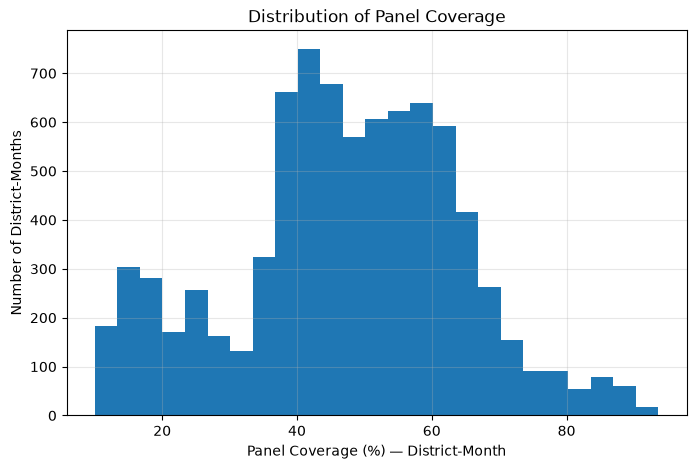

In [20]:
import matplotlib.pyplot as plt

# Find the column containing "coverage"
coverage_col = None
for col in panel_coverage.columns:
    if "coverage" in str(col).lower():
        coverage_col = col
        break

if coverage_col is None:
    raise ValueError(f"No coverage column found. Available columns: {panel_coverage.columns.tolist()}")

print(f"Using coverage column: {coverage_col}")

plt.figure(figsize=(8,5))
plt.hist(panel_coverage[coverage_col].dropna(), bins=25)
plt.xlabel("Panel Coverage (%) — District-Month")
plt.ylabel("Number of District-Months")
plt.title("Distribution of Panel Coverage")
plt.grid(alpha=0.3)
plt.show()

The chart shows that panel coverage is highly uneven across district-months, with most observations concentrated around 40–65% and a substantial number below the 60% reliability threshold, making coverage a key limitation when interpreting sales.


 PANEL COVERAGE QUALITY AUDIT

In [21]:
# PANEL COVERAGE QUALITY AUDIT
print("=== PANEL COVERAGE QUALITY AUDIT ===\n")

coverage = panel_coverage["Panel_Coverage_Pct"]

coverage_summary = pd.DataFrame({
    "metric": [
        "Minimum coverage %",
        "Maximum coverage %",
        "Mean coverage %",
        "Median coverage %",
        "District-months below 60%",
        "District-months at/above 60%",
        "Total district-months"
    ],
    "value": [
        coverage.min(),
        coverage.max(),
        coverage.mean(),
        coverage.median(),
        (coverage < 60).sum(),
        (coverage >= 60).sum(),
        len(coverage)
    ]
})

display(coverage_summary)


=== PANEL COVERAGE QUALITY AUDIT ===



,metric,value
0,Minimum coverage %,10.000000
1,Maximum coverage %,93.630000
2,Mean coverage %,47.231262
3,Median coverage %,47.875000
4,District-months below 60%,6314.000000
5,District-months at/above 60%,1846.000000
6,Total district-months,8160.000000


In [22]:
# NORMALIZED DISTRICT-LEVEL PANEL COVERAGE
panel_coverage_check = panel_coverage.copy()

# Normalize district IDs without modifying the raw dataset
panel_coverage_check["normalized_district_id"] = (
    panel_coverage_check["District_Ref_ID"]
    .map(normalize_district_id)
)

# Calculate average panel coverage across the 24 months
district_coverage = (
    panel_coverage_check
    .groupby("normalized_district_id")["Panel_Coverage_Pct"]
    .mean()
    .reset_index(name="mean_panel_coverage_pct")
)

print("=== NORMALIZED DISTRICT-LEVEL COVERAGE ===")

print(
    "Total districts:",
    len(district_coverage)
)

print(
    "Districts with mean coverage < 60%:",
    (district_coverage["mean_panel_coverage_pct"] < 60).sum()
)

print(
    "Districts with mean coverage >= 60%:",
    (district_coverage["mean_panel_coverage_pct"] >= 60).sum()
)

display(
    district_coverage
    .sort_values("mean_panel_coverage_pct")
    .head(10)
)

=== NORMALIZED DISTRICT-LEVEL COVERAGE ===
Total districts: 340
Districts with mean coverage < 60%: 257
Districts with mean coverage >= 60%: 83


,normalized_district_id,mean_panel_coverage_pct
246,DST_0247,10.704167
70,DST_0071,11.182917
158,DST_0159,11.340417
208,DST_0209,12.164583
75,DST_0076,12.455833
269,DST_0270,13.633333
117,DST_0118,13.879583
157,DST_0158,14.074583
176,DST_0177,15.101667
40,DST_0041,15.219583


CONSOLIDATED CROSS-DATASET RELATIONSHIP AUDIT

In [23]:
# CONSOLIDATED CROSS-DATASET RELATIONSHIP AUDIT
relationship_report = pd.DataFrame([
    {
        "check": "District ID",
        "dataset": row["dataset"],
        "metric": "Normalized match %",
        "value": row["normalized_match_pct"],
        "finding": "All district IDs matched after normalization"
    }
    for _, row in normalized_relationship_audit.iterrows()
] + [
    {
        "check": "District + Month",
        "dataset": row["dataset"],
        "metric": "Match % vs retail panel",
        "value": row["match_pct_vs_retail"],
        "finding": "All district-month combinations matched"
    }
    for _, row in district_month_audit.iterrows()
] + [
    {
        "check": "SKU",
        "dataset": row["dataset"],
        "metric": "Match % vs retail panel",
        "value": row["match_pct_vs_retail"],
        "finding": (
            "All Kestrel SKUs matched to retail panel"
            if row["dataset"] == "kestrel"
            else "Reference dataset"
        )
    }
    for _, row in sku_relationship_audit.iterrows()
])

# Add panel coverage findings
coverage_findings = pd.DataFrame([
    {
        "check": "Panel Coverage",
        "dataset": "panel_coverage",
        "metric": "District-months below 60%",
        "value": int((coverage < 60).sum()),
        "finding": "Low coverage requires caution before using panel data"
    },
    {
        "check": "Panel Coverage",
        "dataset": "panel_coverage",
        "metric": "Districts below 60% mean coverage",
        "value": int(
            (district_coverage["mean_panel_coverage_pct"] < 60).sum()
        ),
        "finding": "District must not be treated as zero demand"
    },
    {
        "check": "Panel Coverage",
        "dataset": "panel_coverage",
        "metric": "Districts at/above 60% mean coverage",
        "value": int(
            (district_coverage["mean_panel_coverage_pct"] >= 60).sum()
        ),
        "finding": "Eligible for panel-based analysis subject to other checks"
    }
])

relationship_report = pd.concat(
    [relationship_report, coverage_findings],
    ignore_index=True
)

display(relationship_report)

# Save Phase 1 relationship audit
from pathlib import Path

output_dir = Path("data/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

relationship_report.to_csv(
    output_dir / "relationship_audit.csv",
    index=False
)

print("\nSaved: data/outputs/relationship_audit.csv")

,check,dataset,metric,value,finding
0,District ID,retail_panel,Normalized match %,100.00,All district IDs matched after normalization
1,District ID,distribution,Normalized match %,100.00,All district IDs matched after normalization
2,District ID,competitor,Normalized match %,100.00,All district IDs matched after normalization
3,District ID,audience,Normalized match %,100.00,All district IDs matched after normalization
4,District ID,kestrel sales,Normalized match %,100.00,All district IDs matched after normalization
...,...,...,...,...,...
13,SKU,retail_panel,Match % vs retail panel,100.00,Reference dataset
14,SKU,kestrel,Match % vs retail panel,20.69,All Kestrel SKUs matched to retail panel
15,Panel Coverage,panel_coverage,District-months below 60%,6314.00,Low coverage requires caution before using pan...
16,Panel Coverage,panel_coverage,Districts below 60% mean coverage,257.00,District must not be treated as zero demand



Saved: data/outputs/relationship_audit.csv


# Audit Summary

## Purpose

This audit was completed before preprocessing or business modeling to establish whether the raw datasets are structurally reliable and to identify limitations that could distort the whitespace analysis.

## Key Findings

- Successfully loaded and inspected all available datasets and verified their structures, columns, data types, and record volumes.

- Identified data-quality issues including substantial exact duplicates, missing values, inconsistent formats, and mixed timestamp representations. These issues are intentionally preserved in the raw data and will be addressed during preprocessing.

- The date/time audit found approximately 92% parsing success across the audited date fields. Several fields contain unparseable values, and the Retail Panel contains future-dated records extending to 2031-11-28. These records are flagged for controlled handling during preprocessing.

- Cross-dataset relationship checks identified inconsistent district ID representations across files. After non-destructive ID normalization, all six analytical datasets align to the same 340 districts.

- District-month relationship checks confirmed 8,160 district-month combinations across the datasets, with 100% alignment to the Retail Panel reference grain.

- SKU relationship checks confirmed that all 6 Kestrel SKUs are represented within the 29 SKUs in the Retail Panel.

- Panel coverage is highly uneven. Coverage ranges from 10.00% to 93.63%, with a mean of 47.23% and median of 47.88%.

- 6,314 of 8,160 district-month observations are below the 60% panel-coverage threshold. At the district level, 257 of 340 districts have mean panel coverage below 60%, while 83 districts meet or exceed 60%.

- Because low panel coverage can make genuine sales appear artificially low, panel coverage must be evaluated before interpreting sales or building the demand signal. Districts below the required coverage threshold will be treated as UNKNOWN rather than as zero-demand markets.

- Exact duplicate rows were identified in several datasets, particularly the Retail Panel, Audience, Kestrel Sales, and Competitor datasets. These duplicates are flagged for investigation during preprocessing rather than removed during the raw-data audit.

## Business Implication

The audit confirms that the raw datasets contain intentional real-world imperfections and uneven panel coverage. The datasets are structurally joinable after controlled normalization, but data-quality issues and panel limitations must be handled before business modeling.

The most important implication is that low observed sales cannot automatically be interpreted as weak demand. The subsequent analysis must distinguish genuine whitespace from weak distribution, weak demand, competitive pressure, and insufficient data.

Raw datasets remain unchanged during Phase 1 so that all preprocessing decisions can be traced and justified in later phases.

Save Audit Summary

In [ ]:
from pathlib import Path

# Create the final outputs folder
output_dir = PROJECT_ROOT / "data" / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

# Export dataset summary
dataset_summary_path = output_dir / "dataset_summary.csv"
summary.to_csv(dataset_summary_path, index=False)

print(f"Dataset summary exported to: {dataset_summary_path}")

# Export cross-dataset relationship audit
relationship_audit_path = output_dir / "relationship_audit.csv"
relationship_report.to_csv(
    relationship_audit_path,
    index=False
)

print(f"Relationship audit exported to: {relationship_audit_path}")

Dataset summary exported to: ..\data\outputs\dataset_summary.csv
Relationship audit exported to: ..\data\outputs\relationship_audit.csv


: 